<h1>PNA Teleconnections - Wind - ERA5 vs SEAS5</h1>

![UFS-logo](../../../UFS-Logo-RGB-2csolidshorizontal-72dpi-min.png)

<h3>PNA index is computed using definition of Wallace and Gutzler (1981)</h3> 
https://doi.org/10.1175/1520-0493(1981)109<0784:TITGHF>2.0.CO;2

In [1]:
basedir = f'../../../..'

In [2]:
import os
import sys
import gc
import collections
from itertools import product
import numpy as np
from io import BytesIO
from PIL import Image
import scipy
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Point to root directory of repository
root_dir = os.path.join(os.getcwd(), basedir)
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from src.datareader import datareader as dr
from src.regridder import Regrid
from src.util import timeutil, stats, pna

import warnings
warnings.filterwarnings('ignore')

<h3>User Configurables</h3>

In [3]:
# seas5 data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/geopotential/'

In [4]:
era5_var = 'geopotential'
seas5_var = 'z'
lev = 500

In [5]:
time_range = ("1994-01-01", "2020-12-31T23")
initmonth = 11  # Only get this init within the time_range

# Form Composites around these leads.
# You could also specify a single lead, like, leads=1
leads = 3 #(0, 1, 2, 3)

In [6]:
# User can pick which dataset gives the "true" PNA phases.
# Normally we'd pick a verification dataset like era5
truthiness = 'era5'
# truthiness = 'seas5'

In [7]:
# For PNA, there are 4 reference locations:
region_1 = {'latmin': 20.0, 'lonmin': 200}
region_2 = {'latmin': 45.0, 'lonmin': 195}
region_3 = {'latmin': 55.0, 'lonmin': 245}
region_4 = {'latmin': 30.0, 'lonmin': 275}

In [8]:
# Define a region over which to calculate pattern correlation.
# You can ignore region by setting it to None
# region = None
region = {
    'latmin': 45,
    'latmax': 90,
    'lonmin': 0,
    'lonmax': 360
}

In [9]:
significance_level = 0.1

In [10]:
# Transform leads into a tuple used for slicing.
if isinstance(leads, int):
    leads = tuple([leads])

<h3>First step is to calculate PNA Index</h3>

<h5>Get data readers</h5>

In [11]:
era5_data_reader = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [12]:
# Collect all seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [13]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [14]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                  'number': 'member'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
seas5_data_reader = dr.getDataReader(datasource='SUPPLIED', dataset=seas5_ds)

In [15]:
seas5_ds = seas5_data_reader.retrieve(var=seas5_var,
                                      initmonths=initmonth,
                                      time=time_range,
                                      member=(0, 24), # We know that seas5 hindcast has members 0-24.
                                      ens_avg=True)

seas5_ds = seas5_ds.sel(pressure_level=lev)

Taking Ensemble Average


In [16]:
era5_ds = timeutil.match_time_to_leads(verif_ds=era5_data_reader.dataset(),
                                       ufs_ds=seas5_ds)

era5_ds = era5_ds.sel(lev=lev)

<h3>Calculate PNA Phases</h3>

In [17]:
if truthiness == 'era5':
    
    print('Processing ERA5 as PNA truth.')
    era5_pna_object = pna.PNA(ds=era5_ds)
    era5_pna_object.calc_phases(var=era5_var)
    
    # Convert these phases to init+lead coordinates based on our chosen initmonth
    era5_pna_object.convert_to_initlead(initmonth=initmonth)
    
    # Store positive and negative phase init+leads
    positive_exclude_initleads = era5_pna_object.positive_exclude_initleads
    negative_exclude_initleads = era5_pna_object.negative_exclude_initleads
    
elif truthiness == 'seas5':
    
    print('Processing SEAS5 as PNA truth.')
    seas5_pna_object = pna.PNA(ds=seas5_ds)
    seas5_pna_object.calc_phases(var=seas5_var)   
    
    # Store positive and negative phase init+leads
    positive_exclude_initleads = seas5_pna_object.positive_exclude_initleads
    negative_exclude_initleads = seas5_pna_object.negative_exclude_initleads

Processing ERA5 as PNA truth.
Results stored in:
<self>.positive_exclude_months
and
<self>.negative_exclude_months
Results stored in:
<self>.positive_exclude_initleads
and
<self>.negative_exclude_initleads


<h1>Now that PNA Index is calculated, we can form Wind composites</h1>

In [18]:
# seas5 data are here:
seas5_dir = '/groups/ORC-CLIMATE/aoes_repo/models/seas5/monthly/mean/uv/'

In [19]:
seas5_var = ['u', 'v']
era5_var = ['u_component_of_wind', 'v_component_of_wind']
lev = 200

In [20]:
# 1 indicator shall refer to VERIF data
data_reader1 = dr.getDataReader(datasource='ERA5')

No filename provided; deferring to default
Reading data from gs://gcp-public-data-arco-era5/ar/1959-2022-6h-512x256_equiangular_conservative.zarr


In [21]:
# 2 indicator shall refer to SEAS5 data
# Our Regridder requires 1 UFS-type data reader.
# What we will do is instantiate a UFS data reader,
# but then supplant its data with the SEAS5 dataset.
data_reader2 = dr.getDataReader(datasource='UFS',                  
                                experiment = 'baseline',
                                # filename=f'experiments/phase_1/{ufs_experiment}/atm_monthly.zarr',
                                model='atm')

No filename provided; deferring to default
Reading data from s3://noaa-oar-sfsdev-pds/experiments/phase_1/baseline/atm_monthly.zarr


In [22]:
# Collect all seas5 files in known directory.
seas5_file_list = os.listdir(seas5_dir)

# Prepend file paths.
seas5_file_list = [os.path.join(seas5_dir, this_file) for this_file in seas5_file_list]

In [23]:
# netcdf4 package is needed here.
seas5_ds = xr.open_mfdataset(seas5_file_list, engine='netcdf4')

In [24]:
# Rename dimensions/coordinates to match our init+lead paradigm.
seas5_ds = seas5_ds.rename_dims({'forecast_reference_time': 'init',
                                 'forecastMonth': 'lead',
                                 'number': 'member',
                                 'pressure_level': 'lev'})

seas5_ds = seas5_ds.rename({'forecast_reference_time': 'init',
                            'forecastMonth': 'lead',
                            'number': 'member',
                            'pressure_level': 'lev'})

# By default the lead unit is defined as '1', but we know it's really 'months'.
seas5_ds['lead'].attrs['units'] = 'months'

# Wrap it up into a DataReader object.
data_reader2.update(ds=seas5_ds) 

Dataset updated.


In [25]:
ds1 = data_reader1.retrieve(var=era5_var, lev=lev)

In [26]:
ds2 = data_reader2.retrieve(var=seas5_var,
                            time=time_range,
                            lev=lev,
                            initmonths=initmonth,
                            lead=(min(leads), max(leads)),
                            member=(0, 24), # We know seas5 hindcast has members 0-24
                            ens_avg=True)

Taking Ensemble Average


In [27]:
# Ensure that temporal domains perfectly match.
ds1 = timeutil.match_time_to_leads(verif_ds=ds1,
                                   ufs_ds=ds2)

In [28]:
# Update datareaders with subsetted and scaled data.
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h5>Instantiate Regridder</h5>

In [29]:
regridder = Regrid.Regrid(data_reader1=data_reader1,                                                              
                          data_reader2=data_reader2,                                                            
                          method='linear')


Regrid Object initialized.

___Resample Instructions___
data_reader1 must be temporally resampled before spatially regridding.
Resample these data by running <RegridObj>.resample(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for resample, run <RegridObj>.resample_vars()

___Regrid Instructions___
Initialized the Regridder with method 'linear'
Input grid shape data_reader1 (ERA5_DataReader): lat 256, lon 512
Output grid shape data_reader2 (UFS_DataReader): lat 180, lon 360
Regrid these data by running <RegridObj>.regrid(var=<var>, lev=<lev>, time=<time_range>)
To see all variables available for regrid, run <RegridObj>.regrid_vars()

___Align Instructions___
data_reader1 can have its time coordinates converted to init+lead.
Lead resolution of the UFS dataset interpreted as monthly intervals.
Align these data by running <RegridObj>.align() (You may need to resample and/or regrid first.)



In [30]:
# Get vars to resample and regrid
vars_to_resample = era5_var
vars_to_regrid = list(globals()[f'data_reader{regridder.highres_grid}'].dataset().keys())
print(f'will resample {vars_to_resample}')
print(f'will regrid {vars_to_regrid}')

will resample ['u_component_of_wind', 'v_component_of_wind']
will regrid ['u_component_of_wind', 'v_component_of_wind']


In [31]:
# RESAMPLE.  (Give this a few minutes to complete.)
regridder.resample(var=vars_to_resample)

Resampling data_reader1 data to 'MS' using mean aggregation.
Resampling from 1994-11-01T00 to 2021-02-28T18
Number of cores available: 12
Finished multiprocessing.  Concatenating results.
Resample completed in 5.49 minutes.
Resample results stored in <RegridObj>.resampled


In [32]:
# REGRID.
regridder.regrid(var=vars_to_regrid)

Regridding data_reader1 grid (ERA5_DataReader) onto data_reader2 grid (UFS_DataReader)
Running spherical harmonics on u_component_of_wind and v_component_of_wind
Completed sperical harmonics in 0.39 minutes.
Regrid results stored in <RegridObj>.regridded


In [33]:
# ALIGN.
regridder.align()

Aligning time coordinate to init+lead coordinates.
MODEL_LEADS: [3]
Time dimensions aligned:  matched 27 timesteps
Align results stored in <RegridObj>.aligned


In [34]:
# Datasets have been pre-processed.
# Need some logic here to extract the results.

# For these notebooks, we know that Verif data are aligned:
ds1 = regridder.aligned.dataset()

# SEAS5 data could be in the regridded slot or not, depending on the experiment we're working with.
if regridder.highres_grid == 2:
    ds2 = regridder.regridded.dataset()
else:
    ds2 = data_reader2.dataset()


In [35]:
data_reader1.update(ds=ds1)
data_reader2.update(ds=ds2)

Dataset updated.
Dataset updated.


<h3>Ready for ONI calculations!</h3>

In [36]:
ds1_positive_statistics = stats.calc_composite_layers(data_reader=data_reader1,
                                                      var=era5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=positive_exclude_initleads)

ds1_negative_statistics = stats.calc_composite_layers(data_reader=data_reader1,
                                                      var=era5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=negative_exclude_initleads)

ds2_positive_statistics = stats.calc_composite_layers(data_reader=data_reader2,
                                                      var=seas5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=positive_exclude_initleads)

ds2_negative_statistics = stats.calc_composite_layers(data_reader=data_reader2,
                                                      var=seas5_var,
                                                      statistics=['anomaly'],
                                                      exclude_initleads=negative_exclude_initleads)

Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.
Calculating climatology statistics and anomalies.
anomaly calculations finished.


In [37]:
# Verify that positive/negative phase-events are properly sorted.
if len(set(list(product(ds1_positive_statistics.init.values, ds1_positive_statistics.lead.values))) &\
    set(list(product(ds1_negative_statistics.init.values, ds1_negative_statistics.lead.values)))) > 0:
    raise ValueError('Duplicate phases identified between positive and negative phases for dataset 1')
    
if len(set(list(product(ds2_positive_statistics.init.values, ds2_positive_statistics.lead.values))) &\
    set(list(product(ds2_negative_statistics.init.values, ds2_negative_statistics.lead.values)))) > 0:
    raise ValueError('Duplicate phases identified between positive and negative phases for dataset 2')

<h3>Run t-tests</h3>

In [38]:
ds1_positive_statistics = ds1_positive_statistics.squeeze(dim=['lev'])
ds1_negative_statistics = ds1_negative_statistics.squeeze(dim=['lev'])
ds2_positive_statistics = ds2_positive_statistics.squeeze(dim=['lev'])
ds2_negative_statistics = ds2_negative_statistics.squeeze(dim=['lev'])

In [39]:
# Get position of init and lead axes
dims = list(ds1_positive_statistics['anomaly'].dims) 
ttest_axes = []
if 'init' in dims:
    ttest_axes.append(dims.index("init"))
if 'lead' in dims:
    ttest_axes.append(dims.index("lead"))

In [40]:
# POSITIVE
anomaly_tstatistic_positive, anomaly_pvalue_positive =\
    scipy.stats.ttest_ind(a=ds1_positive_statistics['anomaly'].values,
                          b=ds2_positive_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

# NEGATIVE
anomaly_tstatistic_negative, anomaly_pvalue_negative =\
    scipy.stats.ttest_ind(a=ds1_negative_statistics['anomaly'].values,
                          b=ds2_negative_statistics['anomaly'].values,
                          axis=ttest_axes,
                          alternative='two-sided')

<h5>Package statistics</h5>

In [41]:
p_values = xr.Dataset(
    data_vars={
        'anomaly_pvalue_positive': (('lat', 'lon'), anomaly_pvalue_positive),
        'anomaly_pvalue_negative': (('lat', 'lon'), anomaly_pvalue_negative)
        
    },
    coords={
        'lat': data_reader1.dataset().lat.values,
        'lon': data_reader1.dataset().lon.values
    }
)

<h3>Anomaly</h3>

In [42]:
# This is the DataArray for the Composite
ds1_positive_composite = ds1_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds1_negative_composite = ds1_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

ds2_positive_composite = ds2_positive_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])
ds2_negative_composite = ds2_negative_statistics['anomaly'].sel(lead=list(leads)).mean(['init', 'lead'])

# Calculate the difference in anomalies
positive_ds2_minus_ds1 = ds2_positive_composite - ds1_positive_composite
negative_ds2_minus_ds1 = ds2_negative_composite - ds1_negative_composite

# Calculate Correlations
positive_corr = xr.corr(ds1_positive_composite, ds2_positive_composite).values.item()
negative_corr = xr.corr(ds1_negative_composite, ds2_negative_composite).values.item()

# Calculate Pattern Correlation over a smaller region
if region is not None:
    
    # latitudes are ordered 90 to -90
    lat_slice = slice(region['latmax'], region['latmin'])
    lon_slice = slice(region['lonmin'], region['lonmax'])
    
    positive_corr_region = xr.corr(ds1_positive_composite.sel(lat=lat_slice, lon=lon_slice),
                                   ds2_positive_composite.sel(lat=lat_slice, lon=lon_slice)).values.item()
    
    negative_corr_region = xr.corr(ds1_negative_composite.sel(lat=lat_slice, lon=lon_slice),
                                   ds2_negative_composite.sel(lat=lat_slice, lon=lon_slice)).values.item()

<h5>Make labels for the plots</h5>

In [43]:
def count_phases(da):
    '''Ad hoc function:  Count the number of init leads with defined data.'''
    n_phases = 0
    # Loop over init-leads
    for this_init in da.init.values:
        for this_lead in da.lead.values:

            # Check if all nan
            if not np.isnan(da.sel(init=this_init, lead=this_lead).values).all():
                n_phases += 1

    return n_phases

In [44]:
n_era5_positive_phases = f"# Positive Phases: {count_phases(ds1_positive_statistics['anomaly'])}"
n_era5_negative_phases = f"# Negative Phases: {count_phases(ds1_negative_statistics['anomaly'])}"

n_seas5_positive_phases = f"# Positive Phases: {count_phases(ds2_positive_statistics['anomaly'])}"
n_seas5_negative_phases = f"# Negative Phases: {count_phases(ds2_negative_statistics['anomaly'])}"

# Label for init and leads
initlead_label = f"init {initmonth}\nlead {' '.join(filter(str.isdigit, str(leads)))}"

# Label for correlation
positive_corr_label = f'corr: {positive_corr:.2f}'
negative_corr_label = f'corr: {negative_corr:.2f}'

if region is not None:
    positive_corr_label = f'{positive_corr_label}\nregion: {positive_corr_region:.2f}'
    negative_corr_label = f'{negative_corr_label}\nregion: {negative_corr_region:.2f}'

<h3>Generate figures</h3>

In [45]:
%%capture captured_output

# Instantiate buffers
buffer1 = BytesIO()
buffer2 = BytesIO()
buffer3 = BytesIO()
buffer4 = BytesIO()
buffer5 = BytesIO()
buffer6 = BytesIO()
buffer7 = BytesIO()

# Make 6 plots
plot_kwargs = {'cmap_label': 'm s-1',
               'cmap': 'custom_btr',
               'topleft_label': initlead_label,
               'dpi': 200}

plot1 = stats.plot_composite(da = ds1_positive_composite,
                             title=f'(a) {data_reader1.datasource} Zonal Wind Anomaly lev={lev} (Positive PNA Phase)',
                             vmin=-9, vmax=9,
                             subtitle=n_era5_positive_phases, **plot_kwargs)

plt.savefig(buffer1, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot2 = stats.plot_composite(da = ds1_negative_composite,
                             title=f'(b) {data_reader1.datasource} Zonal Wind Anomaly lev={lev} (Negative PNA Phase)',
                             vmin=-9, vmax=9,
                             subtitle=n_era5_negative_phases, **plot_kwargs)

plt.savefig(buffer2, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot3 = stats.plot_composite(da = ds2_positive_composite,
                             title=f'(c) SEAS5 Zonal Wind Anomaly lev={lev} (Positive PNA Phase)',
                             vmin=-9, vmax=9,
                             subtitle=n_seas5_positive_phases, **plot_kwargs)

plt.savefig(buffer3, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot4 = stats.plot_composite(da = ds2_negative_composite,
                             title=f'(d) SEAS5 Zonal Wind Anomaly lev={lev} (Negative PNA Phase)',
                             vmin=-9, vmax=9,
                             subtitle=n_seas5_negative_phases, **plot_kwargs)

plt.savefig(buffer4, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot5 = stats.plot_composite(da = positive_ds2_minus_ds1,
                             shading = p_values['anomaly_pvalue_positive'],
                             shading_threshold = significance_level,
                             title=f'(e) SEAS5 minus {data_reader1.datasource} Zonal Wind Anomaly lev={lev} (Positive PNA Phase)',
                             vmin=-4, vmax=4,
                             bottomright_label=positive_corr_label,
                             **plot_kwargs)

plt.savefig(buffer5, format='png', bbox_inches='tight')
# -----------------------------------------------------------------------------

plot6 = stats.plot_composite(da = negative_ds2_minus_ds1,
                             shading = p_values['anomaly_pvalue_negative'],
                             shading_threshold = significance_level,
                             title=f'(f) SEAS5 minus {data_reader1.datasource} Zonal Wind Anomaly lev={lev} (Negative PNA Phase)',
                             vmin=-4, vmax=4,
                             bottomright_label=negative_corr_label,
                             **plot_kwargs)

plt.savefig(buffer6, format='png', bbox_inches='tight')

caption_text = f"""Composites of zonal wind monthly anomaly. Positive PNA phase (left), Negative PNA phase (right).
Panels (a) and (b) show ERA5; Panels (c) and (d) show SEAS5; Panels (e) and (f) show SEAS5 minus ERA5.
Dotted regions are statistically significant at 90%.  For (e) and (f), the lower-right corner shows pattern
correlation between model and verification for the entire domain and for the latitudinal band (region) 45N-90N."""

plt.figure(figsize=(20, 1), facecolor='white')
plt.text(0.15, 0.5,
    caption_text,
    family='serif',
    fontsize=15,
    color='black',
    ha='left',
    va='center')

plt.axis('off')

plt.savefig(buffer7, format='png', bbox_inches='tight')

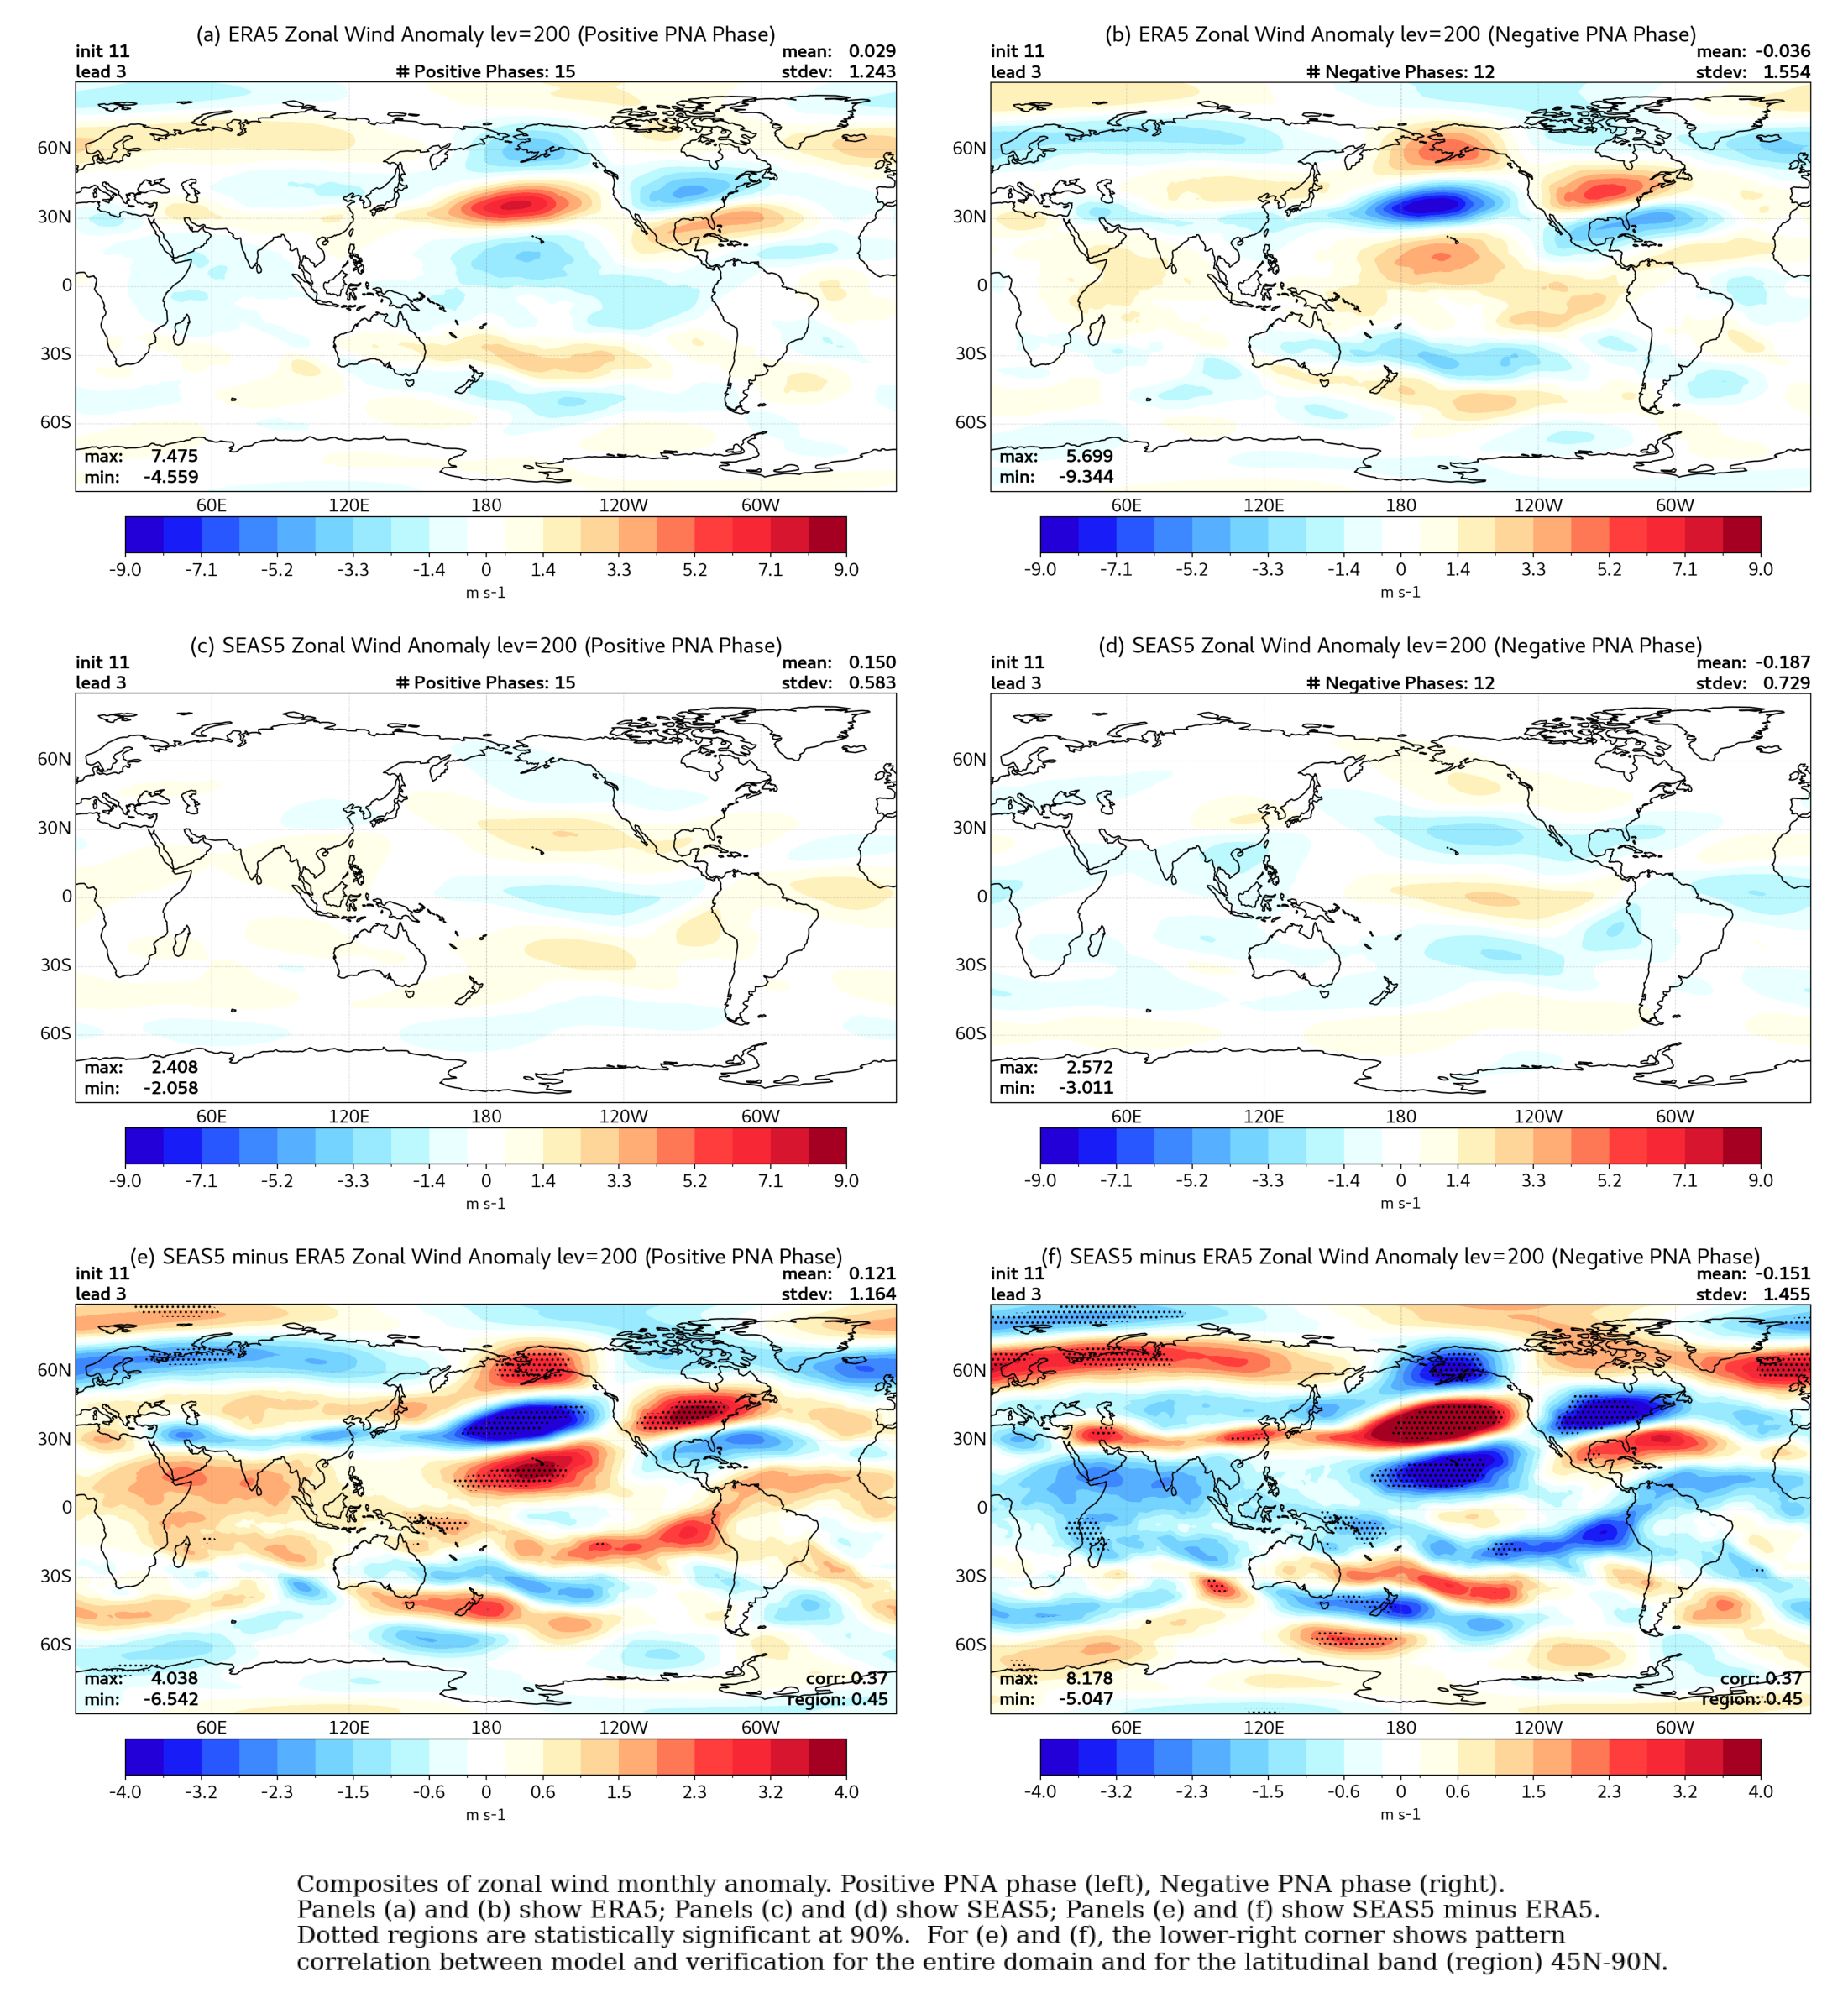

In [46]:
# Layout for mosaic figure
layout = [
    ['A', 'B'],
    ['C', 'D'],
    ['E', 'F'],
    ['G', 'G']]

fig, axd = plt.subplot_mosaic(layout,
                              figsize=(11, 12),
                              gridspec_kw={'height_ratios': [4, 4, 4, 1]},
                              dpi=200)
# Convert to images
image1 = Image.open(buffer1)
image2 = Image.open(buffer2)
image3 = Image.open(buffer3)
image4 = Image.open(buffer4)
image5 = Image.open(buffer5)
image6 = Image.open(buffer6)
image7 = Image.open(buffer7)

# fig, axs = plt.subplots(nrows=3, ncols=2, figsize=(11, 11), dpi=200)

axd['A'].imshow(image1)
axd['A'].axis('off')

axd['B'].imshow(image2)
axd['B'].axis('off')

axd['C'].imshow(image3)
axd['C'].axis('off')

axd['D'].imshow(image4)
axd['D'].axis('off')

axd['E'].imshow(image5)
axd['E'].axis('off')

axd['F'].imshow(image6)
axd['F'].axis('off')

axd['G'].imshow(image7)
axd['G'].axis('off')

plt.gca().set_frame_on(False)
plt.tight_layout(pad=0.5)
plt.show()